Retrieve stock data

In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import yfinance as yf
from datetime import date, timedelta

# define the time period for the data
end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")

# list of stock tickers to download
tickers = ['AAPL', 'MSFT', 'NFLX', 'GOOG', 'TSLA']

data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# reset index to bring Date into the columns for the melt function
data = data.reset_index()

# melt the DataFrame to make it long format where each row is a unique combination of Date, Ticker, and attributes
data_melted = data.melt(id_vars=['Date'], var_name=['Attribute', 'Ticker'])

# pivot the melted DataFrame to have the attributes (Open, High, Low, etc.) as columns
data_pivoted = data_melted.pivot_table(index=['Date', 'Ticker'], columns='Attribute', values='value', aggfunc='first')

# reset index to turn multi-index into columns
stock_data = data_pivoted.reset_index()

print(stock_data.head())

Attribute       Date Ticker   Adj Close       Close        High         Low  \
0         2023-04-12   AAPL  159.249985  160.100006  162.059998  159.779999   
1         2023-04-12   GOOG  105.220001  105.220001  107.586998  104.970001   
2         2023-04-12   MSFT  281.182251  283.489990  287.010010  281.959991   
3         2023-04-12   NFLX  331.029999  331.029999  342.799988  330.040009   
4         2023-04-12   TSLA  180.539993  180.539993  191.580002  180.309998   

Attribute        Open       Volume  
0          161.220001   50133100.0  
1          107.389999   22761600.0  
2          284.790009   27403400.0  
3          340.809998    3965400.0  
4          190.740005  150256300.0  


The data contains the columns




## Date: The date of the stock data entry.
## Ticker: The stock ticker symbol.
## Adj Close: The adjusted closing price of the stock, which accounts for any corporate actions like splits or dividends.
## Close: The closing price of the stock.
## High: The highest price of the stock during the trading day.
## Low: The lowest price of the stock during the trading day.
## Open: The opening price of the stock.
## Volume: The number of shares traded during the day.

Transform dataset

In [ ]:
# convert the 'Date' column to datetime format
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

# set the 'Date' column as the index of the dataframe
stock_data.set_index('Date', inplace=True)
print(stock_data.head())

Attribute  Ticker   Adj Close       Close        High         Low        Open  \
Date                                                                            
2023-04-12   AAPL  159.249985  160.100006  162.059998  159.779999  161.220001   
2023-04-12   GOOG  105.220001  105.220001  107.586998  104.970001  107.389999   
2023-04-12   MSFT  281.182251  283.489990  287.010010  281.959991  284.790009   
2023-04-12   NFLX  331.029999  331.029999  342.799988  330.040009  340.809998   
2023-04-12   TSLA  180.539993  180.539993  191.580002  180.309998  190.740005   

Attribute        Volume  
Date                     
2023-04-12   50133100.0  
2023-04-12   22761600.0  
2023-04-12   27403400.0  
2023-04-12    3965400.0  
2023-04-12  150256300.0  


Visualize the adjusted close prices and volumes for each ticker over time

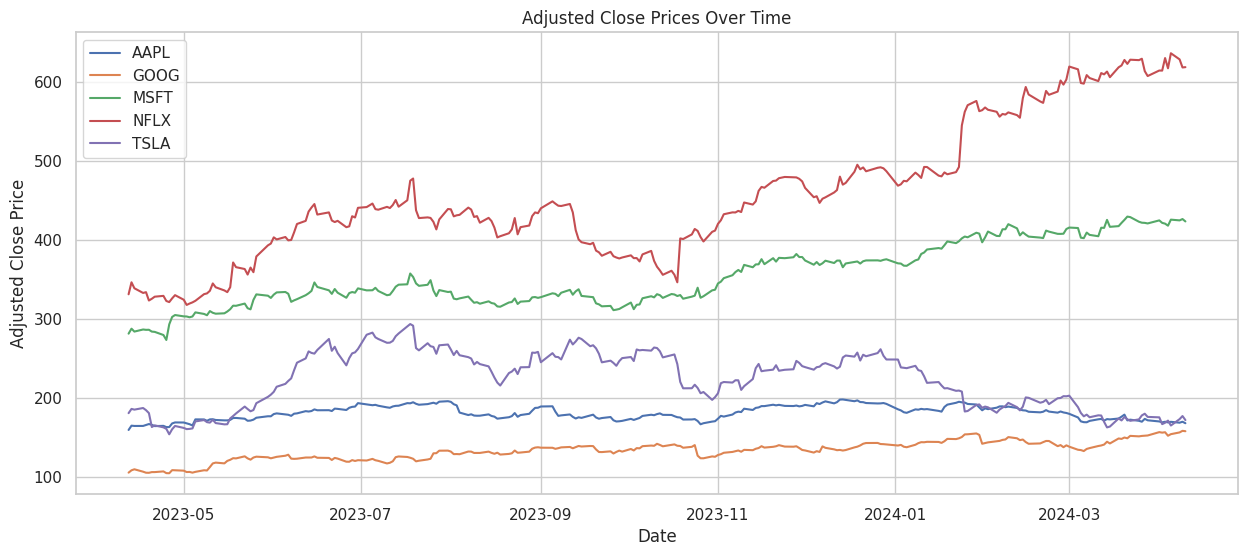

Text(0.5, 0, 'Date')

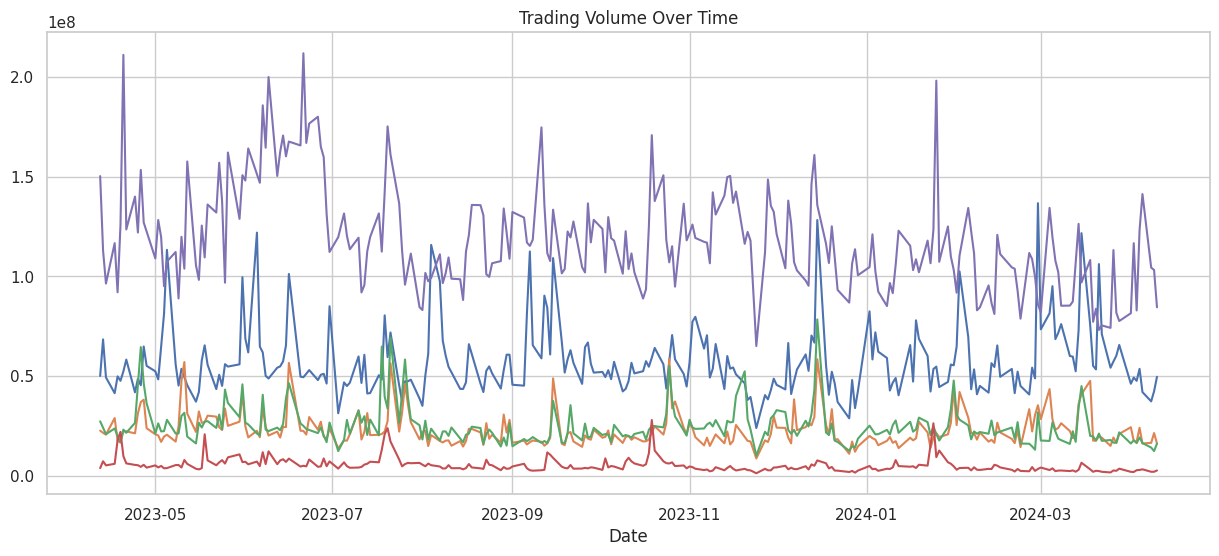

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# plotting the adjusted close prices for each ticker over time
plt.figure(figsize=(15, 6))
for ticker in stock_data['Ticker'].unique():
    subset = stock_data[stock_data['Ticker'] == ticker]
    plt.plot(subset.index, subset['Adj Close'], label=ticker)

plt.title('Adjusted Close Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()

# plotting the trading volume for each ticker over time
plt.figure(figsize=(15, 6))
for ticker in stock_data['Ticker'].unique():
    subset = stock_data[stock_data['Ticker'] == ticker]
    plt.plot(subset.index, subset['Volume'], label=ticker)

plt.title('Trading Volume Over Time')
plt.xlabel('Date')

## AAPL (Apple Inc)
## GOOG (Alphabet Inc)
## MSFT (Microsoft Corporation)
## NFLX (Netflix, Inc.)
## TSLA (Tesla, Inc.)

GOOG appears to have the highest price and shows a general uptrend throughout the period, despite some volatility. TSLA and AAPL also exhibit an uptrend, with AAPL’s stock price increasing more steadily. MSFT and NFLX display relatively lower prices compared to the others, with NFLX showing considerable fluctuation but remaining mostly flat, and MSFT demonstrating a slight downtrend towards the end of the period.

From the second graph, it is evident that AAPL and TSLA have the highest and most volatile trading volumes, with TSLA showing particularly large spikes. It suggests significant investor interest or reactions to events during those times. GOOG, while having the highest stock price, shows moderate and relatively stable trading volume. MSFT and NFLX have lower and less volatile trading volumes in comparison to AAPL and TSLA. The spikes and dips in trading volumes could correspond to earnings reports, product announcements, or other market-moving events for these companies.

# Detecting Anomalies in the Stock Market


Given the variability and trends observed in both adjusted close prices and trading volumes, anomaly detection can focus on identifying:



*   Significant price movements that deviate from the stock’s typical price    

    range or trend.

*   Unusual trading volumes that stand out from the normal trading activity.




For the task of stock market anomaly detection, we can use the Z-score method, which identifies anomalies based on how many standard deviations away a data point is from the mean. A common threshold for identifying an anomaly is a Z-score greater than 2 or less than -2, which corresponds to data points that are more than 2 standard deviations away from the mean.

In [ ]:
from scipy.stats import zscore

def detect_anomalies(df, column):
    df_copy = df.copy()

    # calculate Z-scores and add them as a new column
    df_copy['Z-score'] = zscore(df_copy[column])

    # find where the absolute Z-score is greater than 2 (common threshold for anomalies)
    anomalies = df_copy[abs(df_copy['Z-score']) > 2]
    return anomalies

anomalies_adj_close = pd.DataFrame()
anomalies_volume = pd.DataFrame()

for ticker in stock_data['Ticker'].unique():
    data_ticker = stock_data[stock_data['Ticker'] == ticker]

    adj_close_anomalies = detect_anomalies(data_ticker, 'Adj Close')
    volume_anomalies = detect_anomalies(data_ticker, 'Volume')

    # use concat instead of append
    anomalies_adj_close = pd.concat([anomalies_adj_close, adj_close_anomalies])
    anomalies_volume = pd.concat([anomalies_volume, volume_anomalies])


print(anomalies_adj_close.head())




Attribute  Ticker   Adj Close       Close        High         Low        Open  \
Date                                                                            
2023-04-12   AAPL  159.249985  160.100006  162.059998  159.779999  161.220001   
2023-04-12   GOOG  105.220001  105.220001  107.586998  104.970001  107.389999   
2023-04-13   GOOG  108.190002  108.190002  108.264999  106.440002  106.470001   
2023-04-17   GOOG  106.419998  106.419998  106.709999  105.320000  105.430000   
2023-04-18   GOOG  105.120003  105.120003  107.050003  104.779999  107.000000   

Attribute       Volume   Z-score  
Date                              
2023-04-12  50133100.0 -2.380046  
2023-04-12  22761600.0 -2.279124  
2023-04-13  21650700.0 -2.033627  
2023-04-17  29043400.0 -2.179933  
2023-04-18  17641400.0 -2.287389  


In [ ]:
print(anomalies_volume.head())

Attribute  Ticker   Adj Close       Close        High         Low        Open  \
Date                                                                            
2023-05-05   AAPL  172.648483  173.570007  174.300003  170.759995  170.979996   
2023-05-31   AAPL  176.552780  177.250000  179.350006  176.759995  177.330002   
2023-06-05   AAPL  178.873611  179.580002  184.949997  178.039993  182.630005   
2023-06-16   AAPL  184.192612  184.919998  186.990005  184.270004  186.729996   
2023-08-04   AAPL  181.274155  181.990005  187.380005  181.919998  185.520004   

Attribute        Volume   Z-score  
Date                               
2023-05-05  113316400.0  3.244474  
2023-05-31   99625300.0  2.451171  
2023-06-05  121946500.0  3.744528  
2023-06-16  101235600.0  2.544477  
2023-08-04  115799700.0  3.388364  


Plot the adjusted close prices and trading volumes highlighting the anomalies for each company

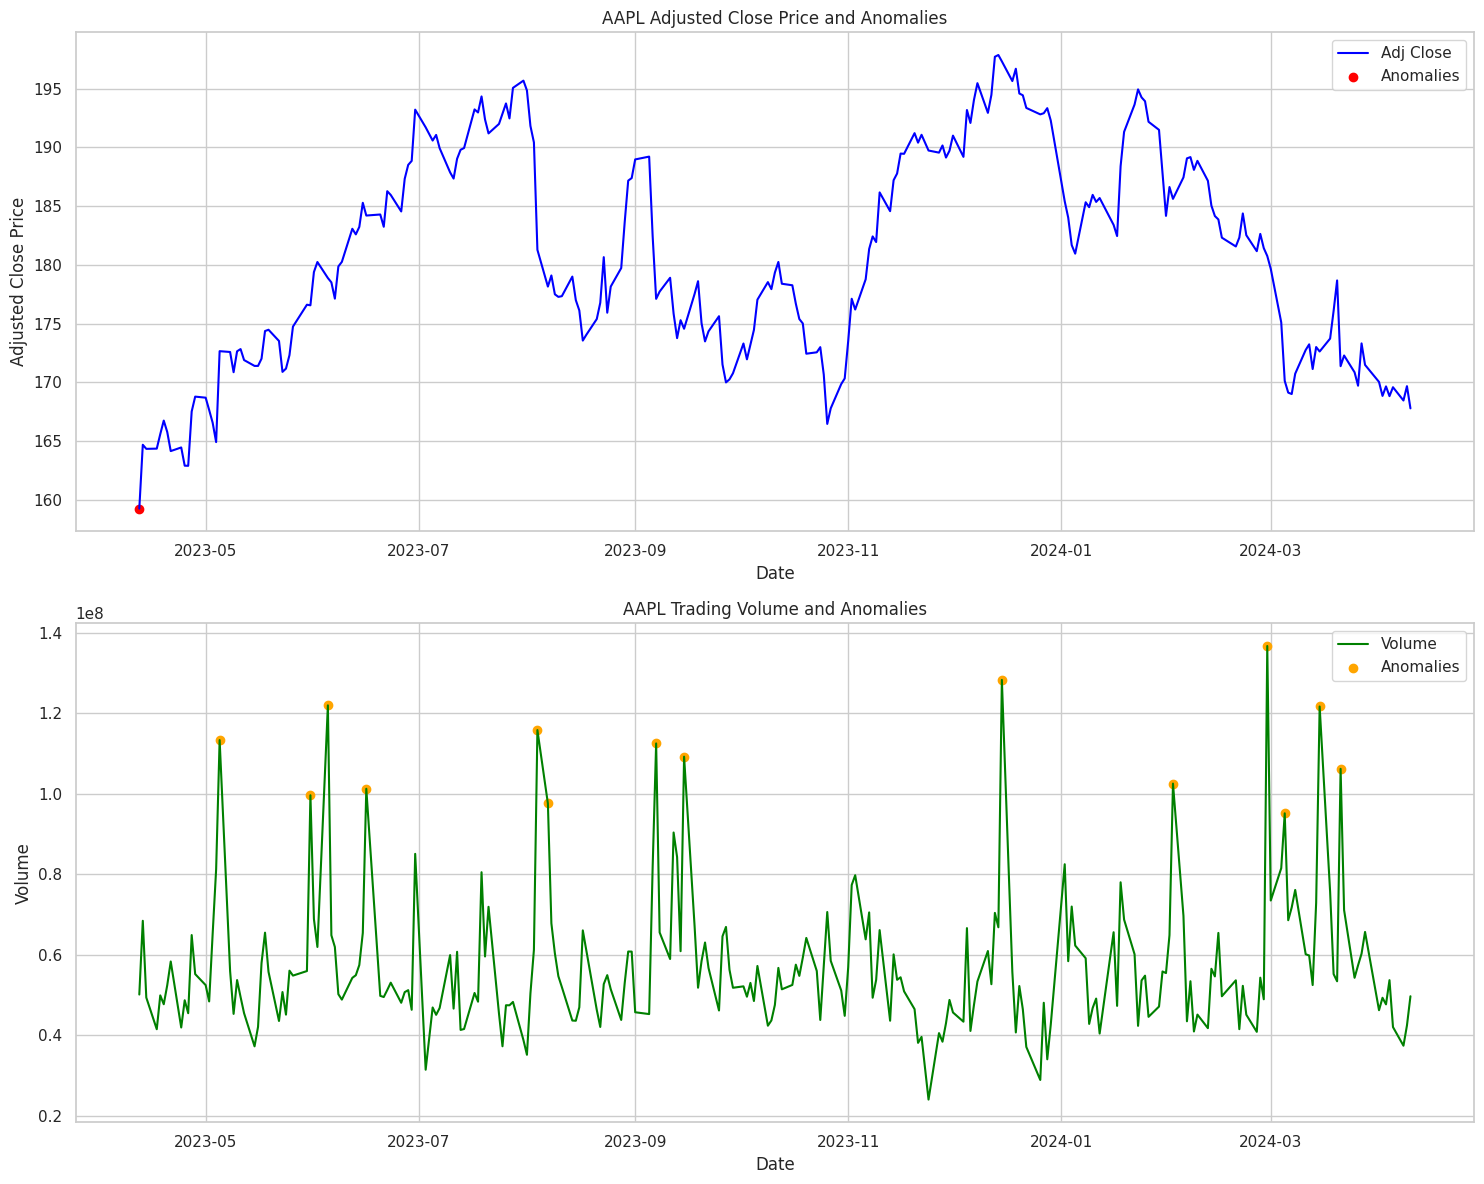

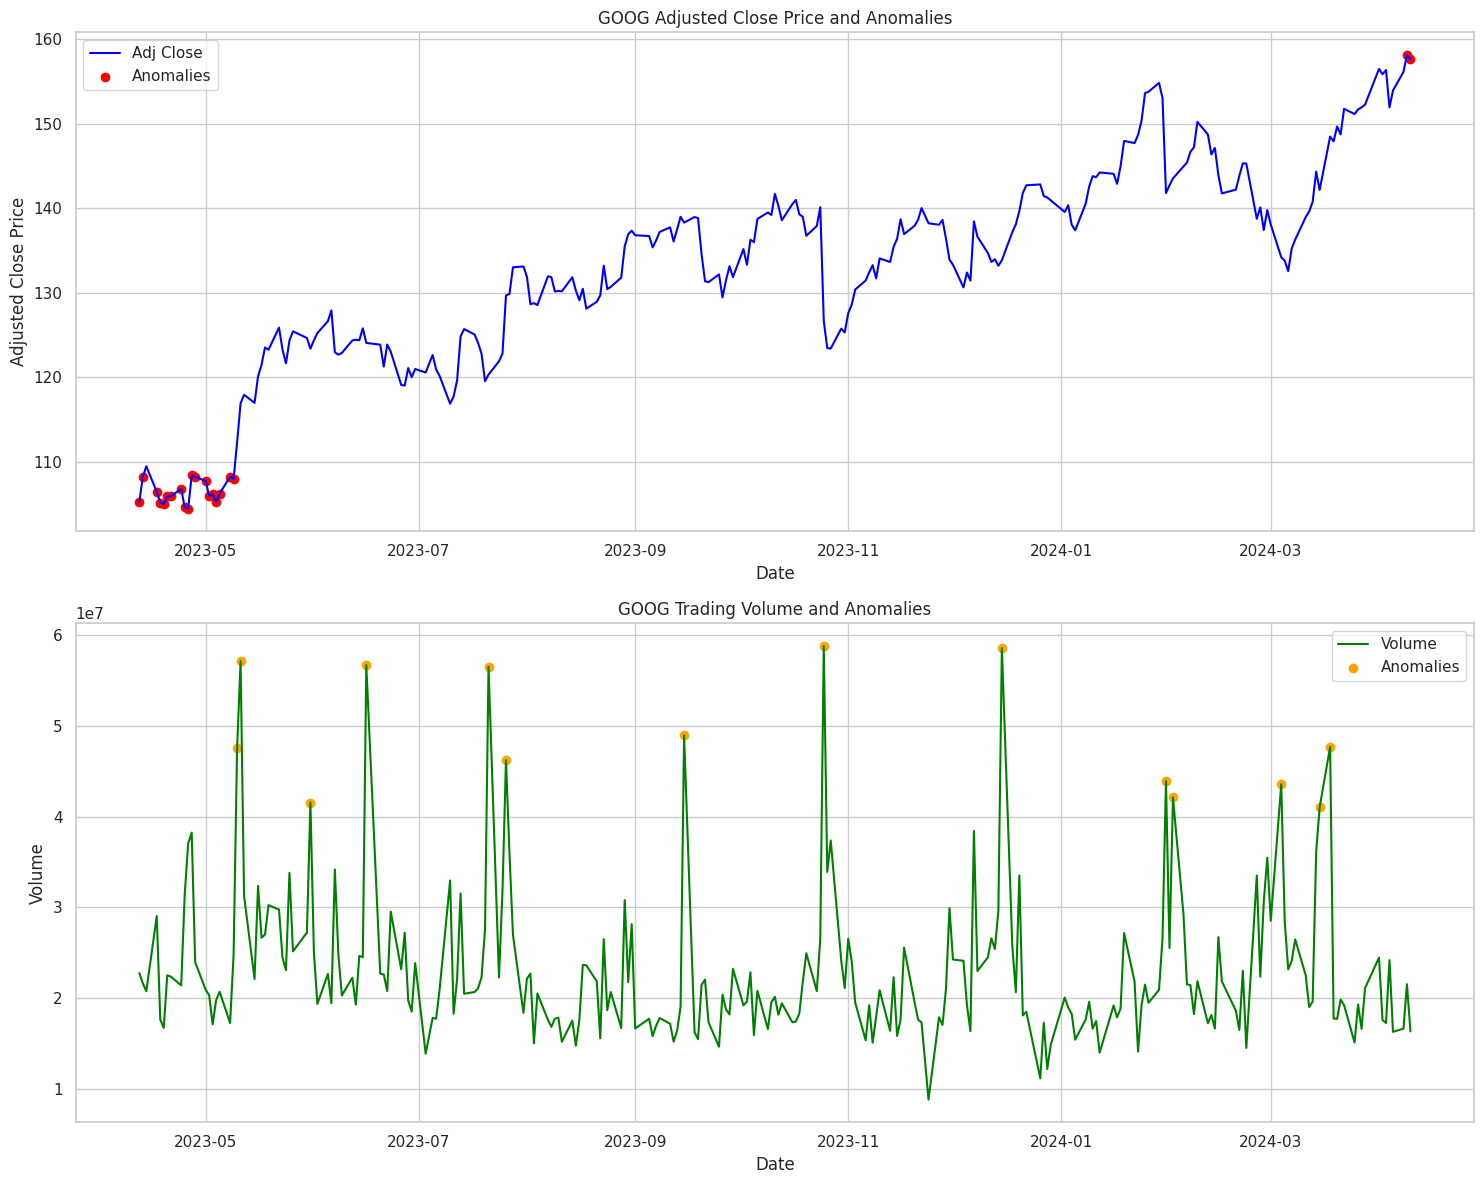

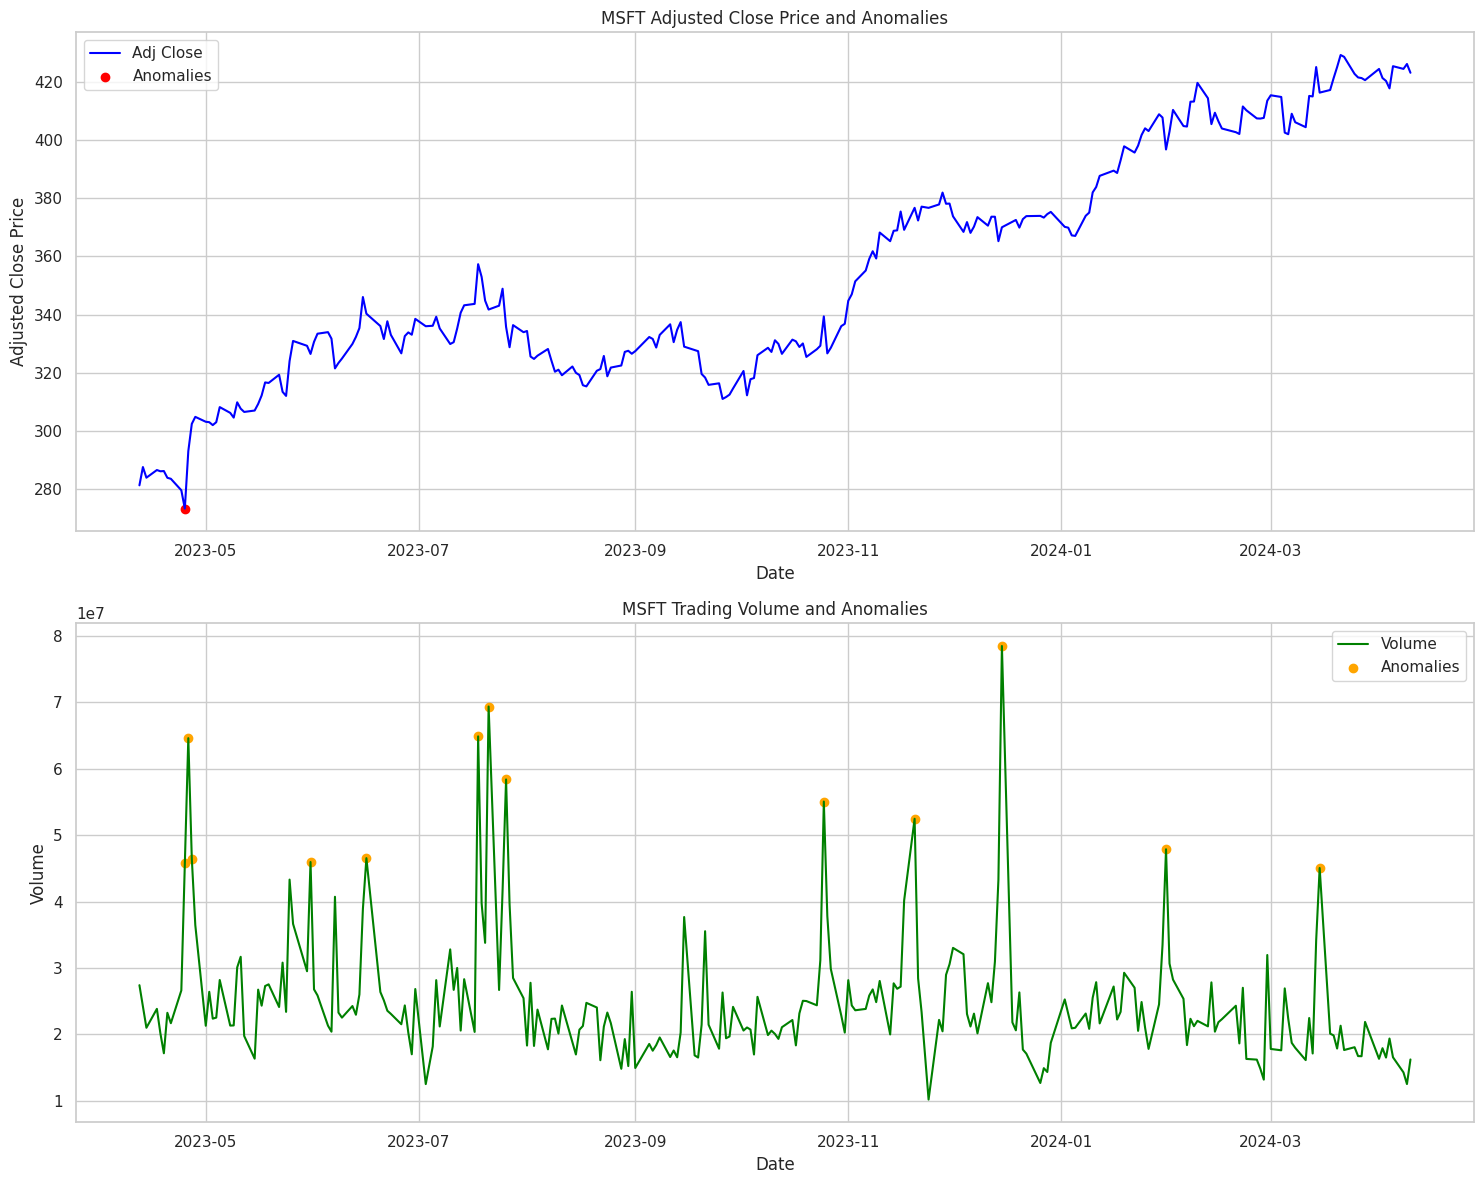

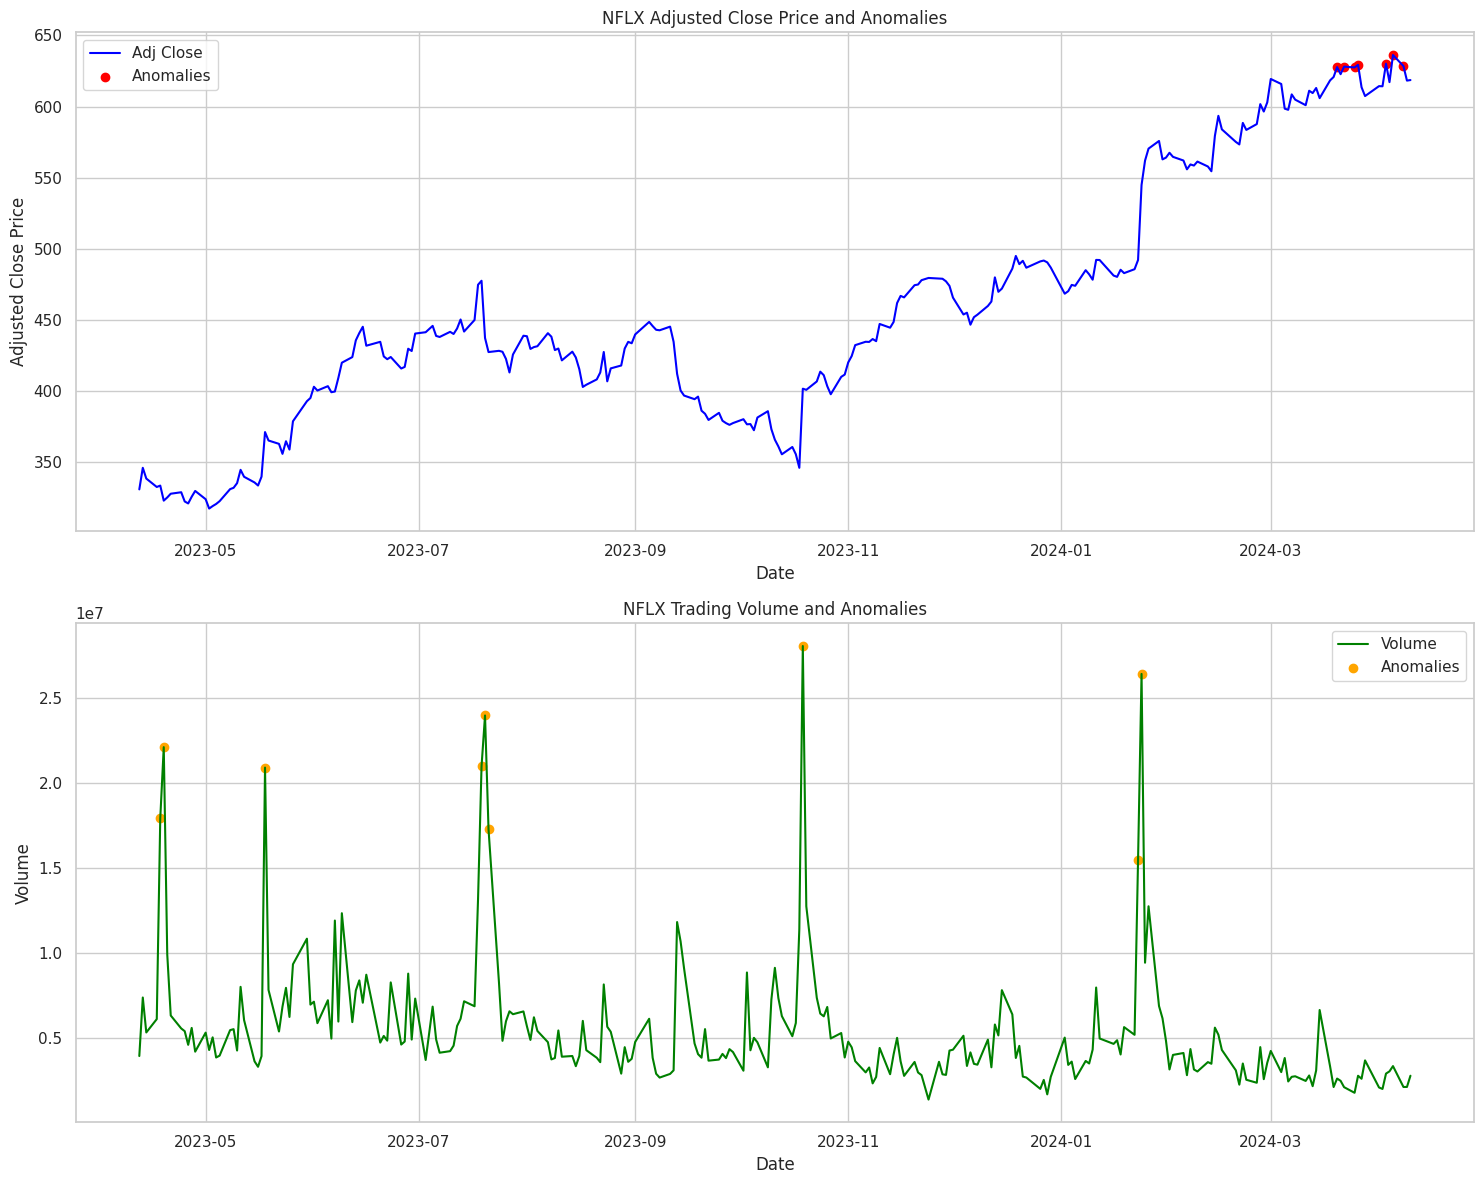

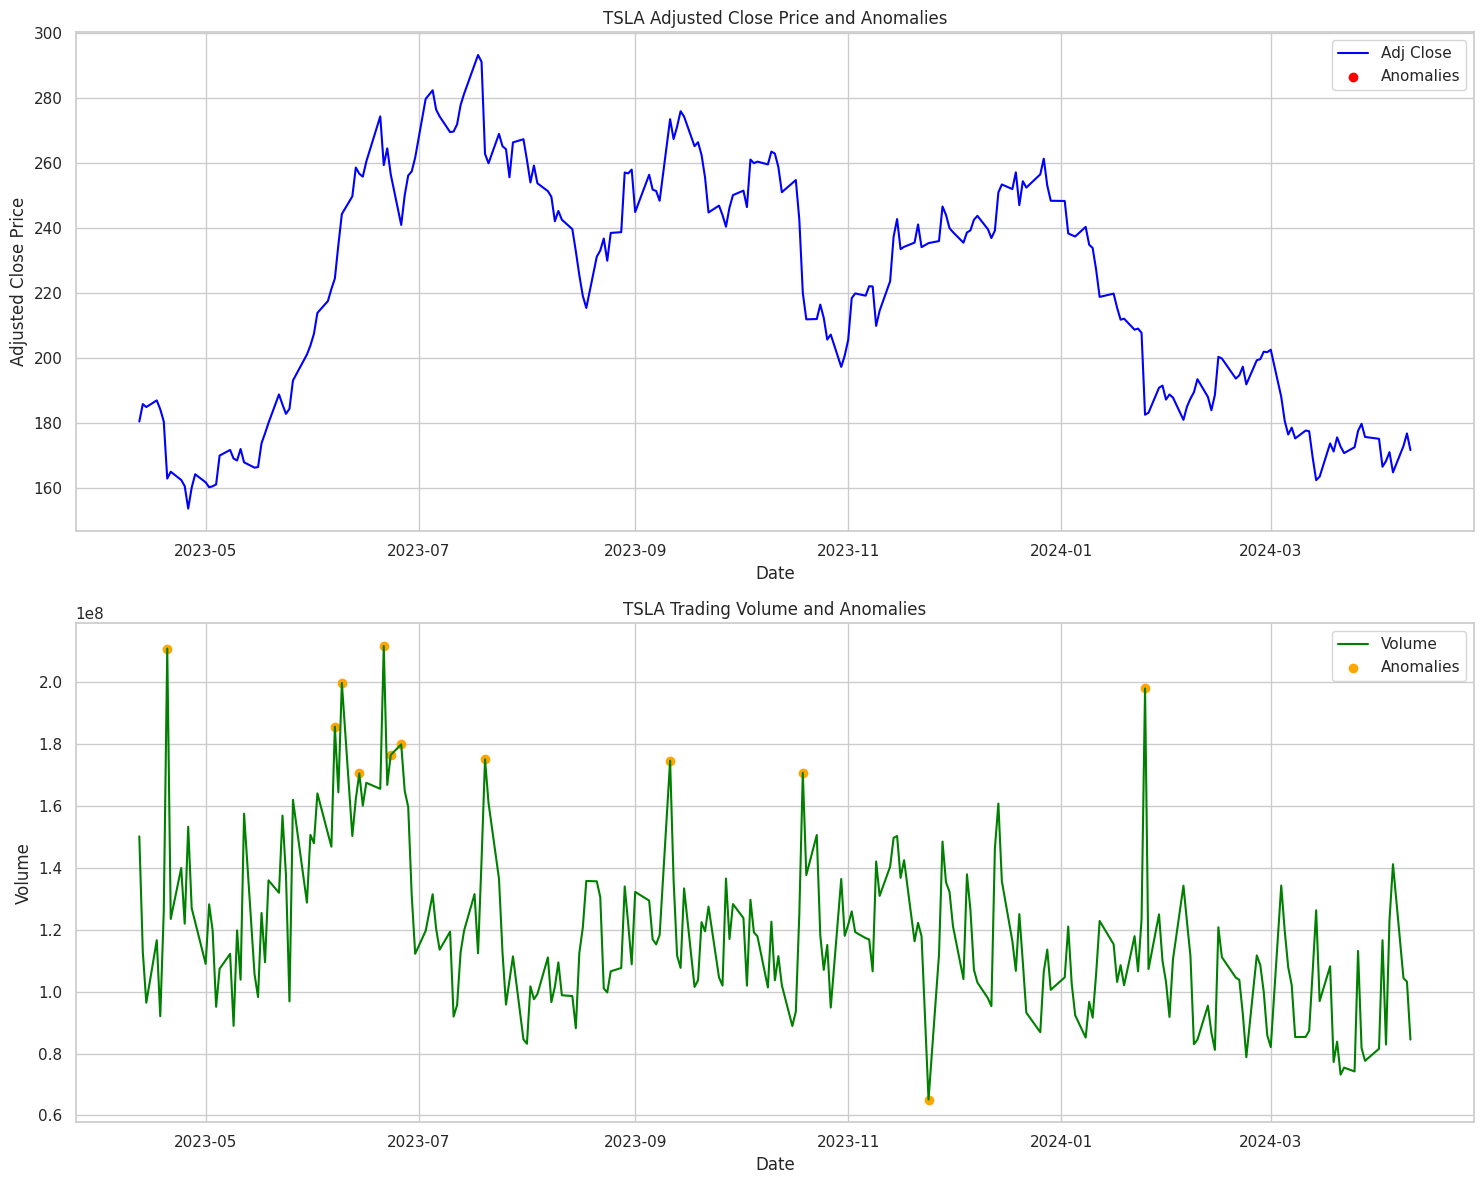

In [ ]:
def plot_anomalies(ticker, anomalies_adj_close, anomalies_volume):
    # Filter the main and anomalies data for the given ticker
    data_ticker = stock_data[stock_data['Ticker'] == ticker]
    adj_close_anomalies = anomalies_adj_close[anomalies_adj_close['Ticker'] == ticker]
    volume_anomalies = anomalies_volume[anomalies_volume['Ticker'] == ticker]

    # plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    # adjusted close price
    ax1.plot(data_ticker.index, data_ticker['Adj Close'], label='Adj Close', color='blue')
    ax1.scatter(adj_close_anomalies.index, adj_close_anomalies['Adj Close'], color='red', label='Anomalies')
    ax1.set_title(f'{ticker} Adjusted Close Price and Anomalies')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Adjusted Close Price')
    ax1.legend()

    # volume
    ax2.plot(data_ticker.index, data_ticker['Volume'], label='Volume', color='green')
    ax2.scatter(volume_anomalies.index, volume_anomalies['Volume'], color='orange', label='Anomalies')
    ax2.set_title(f'{ticker} Trading Volume and Anomalies')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Volume')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# plot anomalies for each ticker
for ticker in stock_data['Ticker'].unique():
  plot_anomalies(ticker, anomalies_adj_close, anomalies_volume)

The above charts for each company display the adjusted close prices and trading volumes over time, with anomalies highlighted:




*   Anomalies are marked in red and represent significant deviations from the  
    typical price range. These could correspond to days with unexpected news, earnings reports, or market shifts.

*   Anomalies in trading volume are marked in orange and indicate days with
    exceptionally high or low trading activity compared to the norm. Such spikes could be due to market events, announcements, or other factors influencing trader behaviour.


Analyze the correlation in the anomalies of all the companies

In [ ]:
# consolidate anomalies for adjusted close prices and volumes
all_anomalies_adj_close = anomalies_adj_close[['Ticker']].copy()
all_anomalies_adj_close['Adj Close Anomaly'] = 1  # indicator variable for anomalies

all_anomalies_volume = anomalies_volume[['Ticker']].copy()
all_anomalies_volume['Volume Anomaly'] = 1  # indicator variable for anomalies

# pivot these dataframes to have one row per date and columns for each ticker, filling non-anomalies with 0
adj_close_pivot = all_anomalies_adj_close.pivot_table(index=all_anomalies_adj_close.index, columns='Ticker',
                                                       fill_value=0, aggfunc='sum')

volume_pivot = all_anomalies_volume.pivot_table(index=all_anomalies_volume.index, columns='Ticker',
                                                fill_value=0, aggfunc='sum')

# flatten the multi-level column index
adj_close_pivot.columns = adj_close_pivot.columns.get_level_values(1)
volume_pivot.columns = volume_pivot.columns.get_level_values(1)

# combine the two pivoted dataframes
combined_anomalies = pd.concat([adj_close_pivot, volume_pivot], axis=1, keys=['Adj Close Anomaly', 'Volume Anomaly'])

# calculate the correlation matrix for the anomalies
correlation_matrix = combined_anomalies.corr()

print(correlation_matrix)

                         Adj Close Anomaly                                \
Ticker                                AAPL      GOOG      MSFT      NFLX   
                  Ticker                                                   
Adj Close Anomaly AAPL            1.000000  0.111111 -0.037037 -0.111111   
                  GOOG            0.111111  1.000000  0.111111 -1.000000   
                  MSFT           -0.037037  0.111111  1.000000 -0.111111   
                  NFLX           -0.111111 -1.000000 -0.111111  1.000000   
Volume Anomaly    AAPL                 NaN       NaN -0.166667       NaN   
                  GOOG                 NaN       NaN       NaN       NaN   
                  MSFT                 NaN       NaN  0.471405       NaN   
                  NFLX                 NaN       NaN -0.258199       NaN   
                  TSLA                 NaN       NaN -0.166667       NaN   

                         Volume Anomaly                                \
Ticker        

AAPL has a low positive correlation with GOOG and a negative correlation with NFLX in terms of adjusted close price anomalies. It suggests that price movements in AAPL have some level of simultaneous occurrence with GOOG but move inversely with NFLX. On the other hand, GOOG and NFLX show a strong negative correlation, indicating that when one experiences an anomalous price increase (or decrease), the other tends to move in the opposite direction.

In trading volumes, GOOG shows a positive correlation with MSFT in trading volume anomalies, suggesting that these companies might have simultaneous unusual trading activities. AAPL’s volume anomalies have a negative correlation with other companies like NFLX and TSLA, indicating that when AAPL experiences unusual trading volume, these companies tend to have opposite anomalies in their trading volumes.

Analyzing the Risk of Anomalies

For this task, we can consider the frequency and magnitude of these anomalies. A stock could be considered more risky if it has frequent and large anomalies in its price or volume. Here’s how we can approach this:


*   Frequency of Anomalies: A higher number of anomalies may indicate a higher
    risk.

*   Magnitude of Anomalies: Larger deviations from the mean (higher absolute
    Z-scores) suggest higher risk.

We can compute a risk score for each stock by combining these factors. For simplicity, we could average the absolute Z-scores of anomalies for each stock and then normalize these scores across all stocks to get a risk rating:

In [ ]:
# calculate the mean absolute Z-score for each stock as a risk indicator
adj_close_risk = anomalies_adj_close.groupby('Ticker')['Z-score'].apply(lambda x: abs(x).mean())
volume_risk = anomalies_volume.groupby('Ticker')['Z-score'].apply(lambda x: abs(x).mean())

# combine the risk scores from both price and volume anomalies
total_risk = adj_close_risk + volume_risk

# normalize the risk scores to get a relative risk rating from 0 to 1
risk_rating = (total_risk - total_risk.min()) / (total_risk.max() - total_risk.min())

print(risk_rating)

Ticker
AAPL    0.299576
GOOG    0.056943
MSFT    0.000000
NFLX    1.000000
TSLA         NaN
Name: Z-score, dtype: float64


AAPL: Has a risk rating of approximately 0.3. It suggests that Apple’s stock shows some level of risk due to anomalies, but it is relatively moderate compared to others like NFLX.

GOOG: With a risk rating of around 0.05, GOOG appears to be less risky compared to AAPL. It indicates fewer or less significant anomalies in its trading data.

MSFT: Shows a risk rating of 0.00, indicating the least risk among the stocks listed. It suggests that Microsoft had the fewest and smallest anomalies in its price and volume data.

NFLX: Has the highest risk rating at 1.00. It indicates that Netflix is the most risky among these stocks, with the most frequent and largest anomalies detected.

TSLA: The NaN value suggests that it did not have detectable anomalies in the period analyzed.

Anomalies in the stock market are important because they can indicate opportunities or risks. For example, a sudden spike in a stock’s price could be due to positive news about the company or its industry, which signals a potential investment opportunity. Conversely, an unexpected price drop could warn of underlying issues or market sentiment changes, which signals a risk that investors may need to manage.